In [1]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_excel('603DA.xlsx')
data

c:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,Branches,Source Name,Status,College Name,Student Name,Admission Date,Enrolled By,Total Fee,Remaining Fee,Course Name,Student Age
0,Nashik,Facebook Ads,Admitted,"JSPM Rajarshi Shahu College of Engineering, Pune",Krishna Kale,2026-02-18,Himani,85000,30000,MERN Stack,21
1,Nagpur,Referral,Admitted,"D.Y. Patil College of Engineering, Akurdi",Pooja Patil,2026-01-28,Tanuja,35000,5000,Data Analytics,20
2,Pune - Hadapsar,Google Search,Closed,"Prof Ram Meghe College of Engineering, Amravati",Kavya Kadam,2025-12-21,Pragati,65000,0,Python Full Stack,24
3,Nashik,WhatsApp Campaign,Active Lead,"Sinhgad College of Engineering, Pune",Rohan Sharma,2026-03-26,Himani,35000,10000,MERN Stack,23
4,Pune - Kothrud,Referral,Closed,"Modern College of Engineering, Pune",Ishaan Jadhav,2026-04-04,Ishwari,35000,20000,Python Full Stack,23
...,...,...,...,...,...,...,...,...,...,...,...
95,Nagpur,YouTube,Closed,"SVERI College of Engineering, Pandharpur",Reyansh Jadhav,2026-01-01,Renuka,45000,22500,Java + Testing + React,26
96,Online,WhatsApp Campaign,Admitted,"SVERI College of Engineering, Pandharpur",Rohan Patil,2026-02-08,Ishwari,75000,15000,Python + Data Analytics,27
97,Mumbai,College Seminar,Admitted,"SVERI College of Engineering, Pandharpur",Kavya Kulkarni,2026-03-03,Tanuja,45000,10000,Java + Testing + React,22
98,Pune - Kothrud,YouTube,Admitted,"SVERI College of Engineering, Pandharpur",Om Shinde,2026-04-02,Shubhangi,35000,20000,Java Full Stack,24


In [4]:
data.isnull().sum()

Branches          0
Source Name       0
Status            0
College Name      5
Student Name      0
Admission Date    0
Enrolled By       0
Total Fee         0
Remaining Fee     0
Course Name       0
Student Age       0
dtype: int64

In [ ]:
# top 4 colleges
data.groupby(by='College Name')['College Name'].value_counts().sort_values(ascending=False).head(4)

College Name
SVERI College of Engineering, Pandharpur           16
Sanjay Ghodawat University, Kolhapur               13
Bharati Vidyapeeth College of Engineering, Pune     9
Prof Ram Meghe College of Engineering, Amravati     8
Name: count, dtype: int64

In [14]:
def agegroup(age):
    if age>20 and age <24:
        return "20-24"
    elif age >24 and age < 27:
        return "24-27"
    else:
        return "27-30"


In [15]:
data['agegroup'] = data['Student Age'].apply(agegroup)

In [23]:
# generate more revinue
data.groupby('agegroup')['Total Fee'].sum().idxmax()

'27-30'

In [ ]:
# data.groupby('agegroup')['Status'].value_counts()
# which age group has the fewest "Payment Pending" students
pending = data[data['Status'] == 'Payment Pending'].groupby('agegroup').size()

pending[pending == pending.min()]



agegroup
24-27    3
27-30    3
dtype: int64

In [ ]:
# Top 3 sources
data.groupby(by='Source Name')['Source Name'].value_counts().sort_values(ascending=False).head(3)

Source Name
YouTube              17
WhatsApp Campaign    15
Facebook Ads         14
Name: count, dtype: int64

In [10]:
def fees_status(fee):
    if fee > 50000:
        return "Premium"
    else:
        return "Normal"

In [ ]:
# add column
data['fees status'] = data['Total Fee'].apply(fees_status)


In [ ]:
# highest addmission by month
data['Month'] = data['Admission Date'].dt.month_name()
data.groupby('Month')['Month'].value_counts().idxmax()

'January'

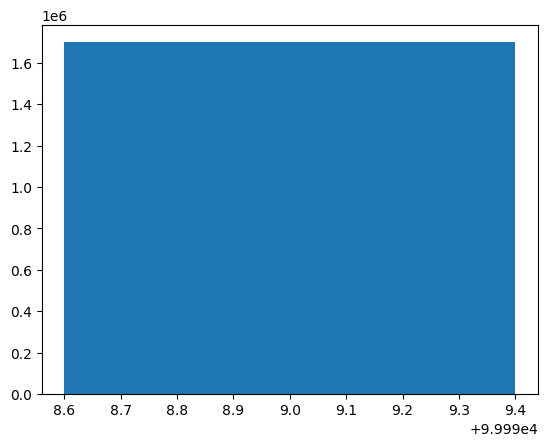

In [37]:
# age - total fees
# source ka graph - admission admitted vs source
import matplotlib.pyplot as plt
age = data.groupby('Total Fee')['Total Fee'].sum().astype('int64')
plt.bar(age.idxmax(),age.max())
plt.show()


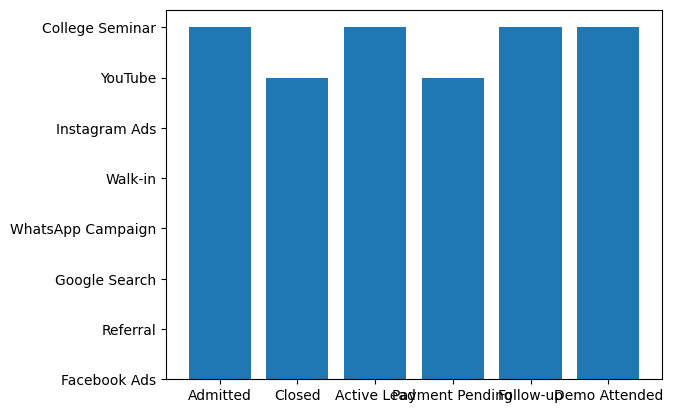

In [ ]:

plt.bar(data['Status'], data['Source Name'])
plt.show()